In [1]:
import torch
import numpy as np
import scipy
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

from tqdm import tqdm

import sklearn
import sklearn.datasets as datasets
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import make_classification

#### Simulate data

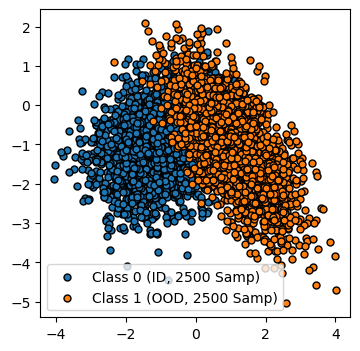

In [2]:
plt.figure(figsize=(4, 4))
X, Y = make_classification(
    n_samples=5000, n_features=2, n_redundant=0, n_informative=2, n_classes=2, n_clusters_per_class=1,
    weights=[0.5, 0.5], class_sep=1.1, random_state=30, shuffle=True, flip_y=0.0
)
text = ["ID", "OOD"]
for i in range(2):
    dat = X[Y == i]
    plt.scatter(dat[:,0], dat[:,1], label=f"Class {str(i)} ({text[i]}, {len(dat)} Samp)", marker="o", s=25, edgecolor="k")
plt.legend()
plt.show()

In [3]:
mask_in = (Y == 0) # Class 0 is in distribution (Class 1 is OOD)
nr_train = 500

X_in = X[mask_in]
Y_in = Y[mask_in]
X_out = X[~mask_in]
Y_out = Y[~mask_in]

X_in_train = X_in[:nr_train]
Y_in_train = Y_in[:nr_train]
X_out_train = X_out[:nr_train]
Y_out_train = Y_out[:nr_train]

X_in_test = X_in[nr_train:]
Y_in_test = Y_in[nr_train:]
X_out_test = X_out[nr_train:]
Y_out_test = Y_out[nr_train:]

print(
    "Train Data In: ", X_in_train.shape, Y_in_train.shape,
    "\nTrain Data Out: ", X_out_train.shape, Y_out_train.shape,
    "\nTest Data In: ", X_in_test.shape, Y_in_test.shape,
    "\nTest Data Out: ", X_out_test.shape, Y_out_test.shape
)

Train Data In:  (500, 2) (500,) 
Train Data Out:  (500, 2) (500,) 
Test Data In:  (2000, 2) (2000,) 
Test Data Out:  (2000, 2) (2000,)


In [4]:
X_train = np.concatenate([X_in_train, X_out_train], axis=0)
Y_train = np.concatenate([Y_in_train, Y_out_train], axis=0)
X_test = np.concatenate([X_in_test, X_out_test], axis=0)
Y_test = np.concatenate([Y_in_test, Y_out_test], axis=0)

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((1000, 2), (1000,), (4000, 2), (4000,))

### Train binary classifier (auxiliary model)

In [5]:
clf = SVC(kernel="rbf", C=1.0)
clf.fit(X_train, Y_train)

# Make predictions on the test set
Y_pred = clf.predict(X_test)

# Evaluate the classifier
accuracy = accuracy_score(Y_test, Y_pred)
print(f'Accuracy: {accuracy:.2f}')

print('Classification Report:')
print(classification_report(Y_test, Y_pred))

# False Positive Rate
fpr = np.sum((Y_pred == 1) & (Y_test == 0)) / np.sum(Y_test == 0) # (H1|H0) / H0
print(f'False Positive Rate: {fpr:.2f}')

Accuracy: 0.91
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      2000
           1       0.88      0.95      0.91      2000

    accuracy                           0.91      4000
   macro avg       0.91      0.91      0.91      4000
weighted avg       0.91      0.91      0.91      4000

False Positive Rate: 0.13


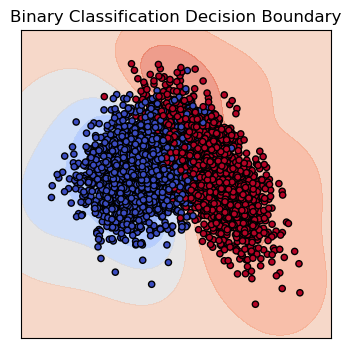

In [6]:
from sklearn.inspection import DecisionBoundaryDisplay

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(4, 4)

disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    response_method = "decision_function",
    cmap=plt.cm.coolwarm,
    alpha=0.7,
    ax=ax
)
ax.scatter(X[:,0], X[:,1], c=Y, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
ax.set_xticks(())
ax.set_yticks(())
ax.set_title("Binary Classification Decision Boundary")

plt.show()


### Stream setting for testing

In [7]:
T = 2000 # nr of time steps
ood_prob = 0.5

# reference (calibration) samples
stream_x1 = np.zeros(shape=(T, 2))
stream_y1 = np.zeros(T)
# test samples
stream_x2 = np.zeros(shape=(T, 2))
stream_y2 = np.zeros(T)

# generate data stream
for t in range(0, T):
    
    # sample from reference (calibration) data
    i = np.random.randint(0, len(X_in_test))
    stream_x1[t] = X_in_test[i]
    stream_y1[t] = Y_in_test[i]
    
    # simulate test sample (in or out of distribution)
    bern = np.random.binomial(1, ood_prob)
    
    if bern == 0: # in distribution
        i = np.random.randint(0, len(X_in_test))
        stream_x2[t] = X_in_test[i]
        stream_y2[t] = Y_in_test[i]
    elif bern == 1: # out of distribution
        i = np.random.randint(0, len(X_out_test))
        stream_x2[t] = X_out_test[i]
        stream_y2[t] = Y_out_test[i]

In [8]:
# Example of a stream of data
for t in range(80, 100):
    print(f"Step {t} | Reference sample: (X,Y) = ({stream_x1[t]}, {stream_y1[t]}) | Test sample: (X,Y) = ({stream_x2[t]}, {stream_y2[t]})")

Step 80 | Reference sample: (X,Y) = ([ 0.41066877 -1.24239378], 0.0) | Test sample: (X,Y) = ([-0.71133138 -1.33964852], 0.0)
Step 81 | Reference sample: (X,Y) = ([-1.7202546  -1.34735113], 0.0) | Test sample: (X,Y) = ([ 1.132384   -0.25118431], 1.0)
Step 82 | Reference sample: (X,Y) = ([-1.95730453 -2.6156837 ], 0.0) | Test sample: (X,Y) = ([ 0.48134142 -0.08605071], 1.0)
Step 83 | Reference sample: (X,Y) = ([-2.57048497 -1.05980547], 0.0) | Test sample: (X,Y) = ([-0.43461268 -0.59273048], 0.0)
Step 84 | Reference sample: (X,Y) = ([-0.31088851 -1.71050346], 0.0) | Test sample: (X,Y) = ([-2.37980773 -2.03012664], 0.0)
Step 85 | Reference sample: (X,Y) = ([-3.26429674 -1.62022491], 0.0) | Test sample: (X,Y) = ([-1.14365309 -0.08532802], 0.0)
Step 86 | Reference sample: (X,Y) = ([-1.42387117 -0.72890507], 0.0) | Test sample: (X,Y) = ([-0.71097266 -0.63970568], 0.0)
Step 87 | Reference sample: (X,Y) = ([-1.63278081 -2.26747397], 0.0) | Test sample: (X,Y) = ([-0.06033238  0.01859097], 0.0)


### Evidence collectors

In [9]:
# ONS algorithm for betting strategy update
def lam_ons(v, lam, a): 
    z = v / (1 - v * lam)
    a = a + z**2
    lam = min(0.5, max(-0.5, lam - (2 / 2 - np.log(3)) * (z / a)))
    return lam, a

# Shekhar & Ramdas 2023 - two sample testing
def betting_twosamp(pred_x1, pred_x2, prev_eval, lam, a):
    v = (pred_x2 - pred_x1) # has to be in [-1, 1]
    assert v >= -1 and v <= 1
    
    lam, a = lam_ons(v, lam, a)
    evidence = prev_eval * (1 + lam * v)
    return evidence, lam, a

# Shekhar & Ramdas 2023 - one sample testing
def betting_onesamp(exp_h0, pred_x2, prev_eval, lam, a):
    v = (pred_x2 - exp_h0) # has to be in [-1, 1]
    assert v >= -1 and v <= 1
    
    lam, a = lam_ons(v, lam, a)
    evidence = prev_eval * (1 + lam * v)
    return evidence, lam, a


### Stream prediction and evidence collection

In [177]:
alpha = 0.1 # target fpr
stream_fpr = np.zeros(T)

stream_pred_x1 = np.zeros(T)
stream_pred_x2 = np.zeros(T)

stream_eval = np.ones(T)
stream_lam = np.zeros(T)
# evidence params init
lam = 0.0
a = 1.0

for t in tqdm(range(0, T), desc="Time steps"):
    
    pred_x1 = clf.predict(stream_x1[t].reshape(1, -1))[0] # reference pred
    pred_x2 = clf.predict(stream_x2[t].reshape(1, -1))[0] # test pred
    
    stream_pred_x1[t] = pred_x1
    stream_pred_x2[t] = pred_x2
    
    # stream_fpr[t] = np.nan_to_num(np.sum((stream_pred_x2[:t+1] == 1) & (stream_y2[:t+1] == 0)) / np.sum(stream_y2[:t+1] == 0), nan=0.0)
    stream_fpr[t] = np.nan_to_num(np.sum((stream_pred_x2[:t+1] == 1) & (stream_y2[:t+1] == 0)) / np.sum(stream_y2 == 0), nan=0.0)
    
    if (t > 0):
        
        evidence, lam, a = betting_twosamp(pred_x1, pred_x2, stream_eval[t-1], lam, a)
        # evidence, lam, a = betting_onesamp(ood_prob, pred_x2, stream_eval[t-1], lam, a)
        
        stream_eval[t] = evidence
        stream_lam[t] = lam

Time steps: 100%|██████████| 2000/2000 [00:00<00:00, 2157.61it/s]


### Evaluate stopping times

Optimal stopping time based on empirically tracked FPR (requires labels at every time step)

In [178]:
t_candidate = np.where(stream_fpr >= alpha)[0]
if len(t_candidate) == 0:
    t_opt = T
else:
    t_opt = t_candidate.min()

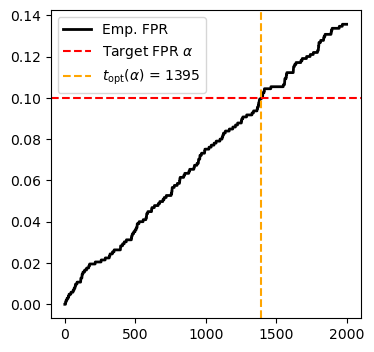

In [179]:
plt.figure(figsize=(4, 4))
plt.plot(stream_fpr, label="Emp. FPR", color="black", lw=2)
plt.axhline(y=alpha, color="red", linestyle="--", label=r"Target FPR $\alpha$")
plt.axvline(x=t_opt, color="orange", linestyle="--", label=r"$t_{\text{opt}}(\alpha)$ = " + str(t_opt))
# plt.ylim(-0.01, 0.15)
# plt.xlim(1600, 1800)
plt.legend()
plt.show()

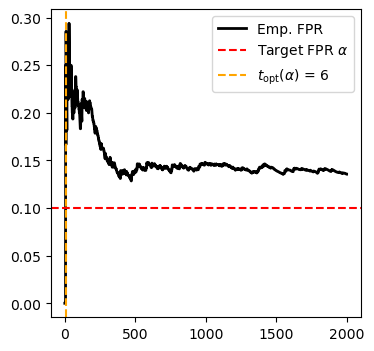

In [176]:
plt.figure(figsize=(4, 4))
plt.plot(stream_fpr, label="Emp. FPR", color="black", lw=2)
plt.axhline(y=alpha, color="red", linestyle="--", label=r"Target FPR $\alpha$")
plt.axvline(x=t_opt, color="orange", linestyle="--", label=r"$t_{\text{opt}}(\alpha)$ = " + str(t_opt))
# plt.ylim(-0.01, 0.15)
# plt.xlim(1600, 1800)
plt.legend()
plt.show()

Stopping time based on testing by betting

In [92]:
t_ev_candidate = np.where(stream_eval >= 1/alpha)[0]
if len(t_ev_candidate) == 0:
    t_ev = T
else:
    t_ev = t_ev_candidate.min()

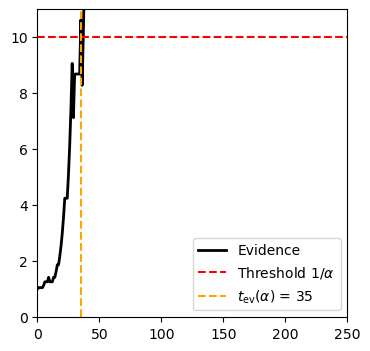

In [93]:
plt.figure(figsize=(4, 4))
plt.plot(stream_eval, label="Evidence", color="black", lw=2)
plt.axhline(y=1/alpha, color="red", linestyle="--", label=r"Threshold $1/\alpha$")
plt.axvline(x=t_ev, color="orange", linestyle="--", label=r"$t_{\text{ev}}(\alpha)$ = " + str(t_ev))
plt.ylim(-0.01, 1/alpha + 1)
plt.xlim(0, 250)
plt.legend()
plt.show()

In [95]:
for t in range(0, 10):
    print(f"Step {t} | (True Ref, True Test) = ({stream_y1[t]}, {stream_y2[t]}) | (Pred Ref, Pred Test) = ({stream_pred_x1[t]}, {stream_pred_x2[t]}) | Evidence = {stream_eval[t]}")

Step 0 | (True Ref, True Test) = (0.0, 0.0) | (Pred Ref, Pred Test) = (0.0, 0.0) | Evidence = 1.0
Step 1 | (True Ref, True Test) = (0.0, 1.0) | (Pred Ref, Pred Test) = (0.0, 1.0) | Evidence = 1.049306144334055
Step 2 | (True Ref, True Test) = (0.0, 0.0) | (Pred Ref, Pred Test) = (0.0, 0.0) | Evidence = 1.049306144334055
Step 3 | (True Ref, True Test) = (0.0, 1.0) | (Pred Ref, Pred Test) = (1.0, 1.0) | Evidence = 1.049306144334055
Step 4 | (True Ref, True Test) = (0.0, 0.0) | (Pred Ref, Pred Test) = (0.0, 0.0) | Evidence = 1.049306144334055
Step 5 | (True Ref, True Test) = (0.0, 1.0) | (Pred Ref, Pred Test) = (0.0, 1.0) | Evidence = 1.1360808666666176
Step 6 | (True Ref, True Test) = (0.0, 0.0) | (Pred Ref, Pred Test) = (0.0, 1.0) | Evidence = 1.2584683498905949
Step 7 | (True Ref, True Test) = (0.0, 0.0) | (Pred Ref, Pred Test) = (0.0, 0.0) | Evidence = 1.2584683498905949
Step 8 | (True Ref, True Test) = (0.0, 0.0) | (Pred Ref, Pred Test) = (0.0, 0.0) | Evidence = 1.2584683498905949
St

Betting strategy behaviour (higher: more aggressive bet, lower: more conservative bet)

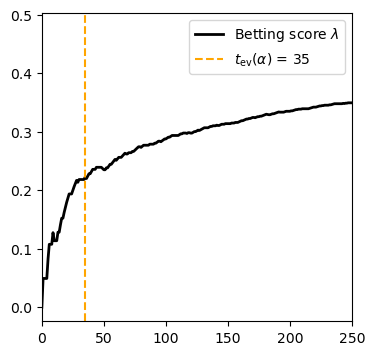

In [94]:
plt.figure(figsize=(4, 4))
plt.plot(stream_lam, label=r"Betting score $\lambda$", color="black", lw=2)
plt.axvline(x=t_ev, color="orange", linestyle="--", label=r"$t_{\text{ev}}(\alpha)$ = " + str(t_ev))
plt.xlim(0, 250)
plt.legend()
plt.show()

### Slow-down Ideas

Instead of multiplying, the wealth process averages evidence over time steps. This slows down growth rate, while averaging is also an admissible way of merging e-values

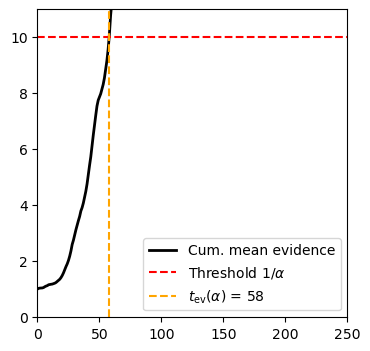

In [17]:
stream_cum = np.cumsum(stream_eval) / np.arange(1, T+1)

t_ev_candidate = np.where(stream_cum >= 1/alpha)[0]
if len(t_ev_candidate) == 0:
    t_ev = T
else:
    t_ev = t_ev_candidate.min()

plt.figure(figsize=(4, 4))
plt.plot(stream_cum, label="Cum. mean evidence", color="black", lw=2)
plt.axhline(y=1/alpha, color="red", linestyle="--", label=r"Threshold $1/\alpha$")
plt.axvline(x=t_ev, color="orange", linestyle="--", label=r"$t_{\text{ev}}(\alpha)$ = " + str(t_ev))
plt.ylim(-0.01, 1/alpha + 1)
plt.xlim(0, 250)
plt.legend()
plt.show()

Use log(E) instead of E-values to slow growth

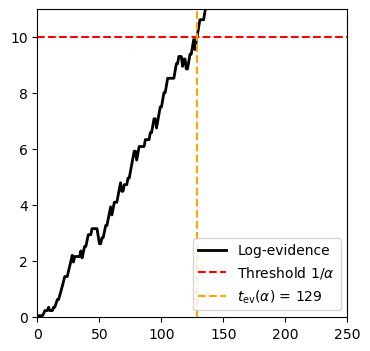

In [97]:
stream_logeval = np.log(stream_eval)

t_ev_candidate = np.where(stream_logeval >= 1/alpha)[0]
if len(t_ev_candidate) == 0:
    t_ev = T
else:
    t_ev = t_ev_candidate.min()

plt.figure(figsize=(4, 4))
plt.plot(stream_logeval, label="Log-evidence", color="black", lw=2)
plt.axhline(y=1/alpha, color="red", linestyle="--", label=r"Threshold $1/\alpha$")
plt.axvline(x=t_ev, color="orange", linestyle="--", label=r"$t_{\text{ev}}(\alpha)$ = " + str(t_ev))
plt.ylim(-0.01, 1/alpha + 1)
plt.xlim(0, 250)
plt.legend()
plt.show()

Use a betting strategy that relies directly on estimated slope of stream FPR

In [182]:
N = 500 # calibration samples

cal_x = np.zeros(shape=(N, 2))
cal_y = np.zeros(N)
cal_pred = np.zeros(N)
cal_fpr = np.zeros(N)

# generate data stream
for n in tqdm(range(0, N), desc="Calibration samples"):
    
    # sample from reference (calibration) data
    i = np.random.randint(0, len(X_in_test))
    cal_x[n] = X_in_test[i]
    cal_y[n] = Y_in_test[i]
    
    cal_pred[n] = clf.predict(X_in_test[i].reshape(1, -1))[0]
    # cal_fpr[n] = np.sum((cal_pred[:n+1] == 1) & (cal_y[:n+1] == 0)) / np.sum(cal_y[:n+1] == 0)
    cal_fpr[n] = np.sum((cal_pred[:n+1] == 1) & (cal_y[:n+1] == 0)) / np.sum(cal_y == 0)

cal_x.shape, cal_y.shape, cal_pred.shape, cal_fpr.shape

Calibration samples: 100%|██████████| 500/500 [00:00<00:00, 3090.11it/s]


((500, 2), (500,), (500,), (500,))

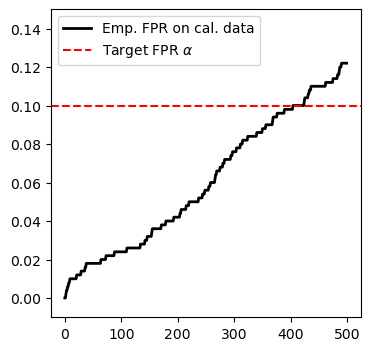

In [183]:
plt.figure(figsize=(4, 4))
plt.plot(cal_fpr, label="Emp. FPR on cal. data", color="black", lw=2)
plt.axhline(y=alpha, color="red", linestyle="--", label=r"Target FPR $\alpha$")
plt.ylim(-0.01, 0.15)
# plt.xlim(1600, 1800)
plt.legend()
plt.show()

In [184]:
from sklearn.linear_model import LinearRegression

x = np.arange(N).reshape(-1, 1)
model = LinearRegression().fit(x, cal_fpr)

slope = model.coef_[0]
bias = model.intercept_

print(f"Linear regression: y = {slope:.6f} * x + {bias:.6f}")

Linear regression: y = 0.000241 * x + 0.000562


In [185]:
model.predict(np.array([[400]]))[0]

0.097040037248149

In [186]:
stream_eval_slope = np.ones(T)

for t in tqdm(range(0, T), desc="Time steps"):
    
    stream_pred_x1[t] = pred_x1
    stream_pred_x2[t] = pred_x2
    
    if (t > 0):
        
        v = (pred_x2 - pred_x1)
        lam = slope
        evidence = stream_eval_slope[t-1] * (1 + lam * v)
        stream_eval_slope[t] = evidence

Time steps: 100%|██████████| 2000/2000 [00:00<00:00, 252943.19it/s]


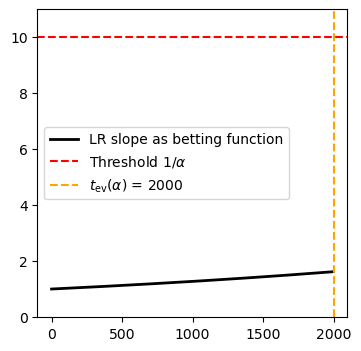

In [187]:
t_ev_candidate = np.where(stream_eval_slope >= 1/alpha)[0]
if len(t_ev_candidate) == 0:
    t_ev = T
else:
    t_ev = t_ev_candidate.min()

plt.figure(figsize=(4, 4))
plt.plot(stream_eval_slope, label="LR slope as betting function", color="black", lw=2)
plt.axhline(y=1/alpha, color="red", linestyle="--", label=r"Threshold $1/\alpha$")
plt.axvline(x=t_ev, color="orange", linestyle="--", label=r"$t_{\text{ev}}(\alpha)$ = " + str(t_ev))
plt.ylim(-0.01, 1/alpha + 1)
# plt.xlim(0, 250)
plt.legend()
plt.show()